In [1]:
import numpy as np
import copy
import sys
import torch  
import h5py
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as td
from torch.autograd import Variable
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from tqdm import tqdm, trange
import IPython
import random
from collections import namedtuple
from operator import attrgetter
import itertools
from IPython.display import clear_output
from pylab import meshgrid, imshow, title, colorbar, show

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
#random.seed(0)

In [3]:
# If using notebook in dark mode
plt.style.use(['dark_background', 'bmh'])
plt.rc('axes', facecolor='k')
plt.rc('figure', facecolor='k')

In [8]:
# Load Data
data_file = "./STM_DataFile_AfterImgs.h5"
f = h5py.File(data_file, "r")

# Load input data and resize to desired shape
inputs = torch.tensor(np.stack(f['input_data'][:])/255.0).unsqueeze(1).to(device)
input_shape = (48, 48)
resize = transforms.Resize(input_shape)
inputs = resize(inputs)

# Convert one-hot-encoded outputs to integers for multi-class classification
outputs = f['output_data'][:]
num_class = outputs.shape[1]
outputs = [np.where(r==1)[0][0] for r in outputs]
outputs = torch.tensor(np.stack(outputs), dtype=torch.int).to(device)

# Split into training and validation set
train_x, val_x, train_y, val_y = train_test_split(inputs, outputs, test_size=0.1, shuffle=True)

In [27]:
def IndependentNormal(loc, scale, loc_range=None, scale_range=None):
    if loc_range is not None:
        loc = torch.clip(loc, loc_range[0], loc_range[1])
    if scale_range is not None:
        scale = torch.clip(scale, scale_range[0], scale_range[1])
        
    return td.independent.Independent(td.normal.Normal(loc, scale), 1)

def train(model, compute_loss, train_data, optimizer, validation_data=None, 
          beta=None, scheduler=None, epochs=500, batch_size=32, clip_grad_norm=None):
    
    disable = True
    if validation_data is not None:
        losses = np.full((epochs, 2), np.nan)
        disable = False
        
    with trange(epochs, desc="Training Model", disable = disable) as pbar:
        for epoch in pbar:
            running_loss = 0.0
            train_x, train_y = train_data
            
            for j in range(0, len(train_x), batch_size):
                model.train()
                if beta is not None:
                    loss = compute_loss((train_x[j:j + batch_size], train_y[j:j + batch_size]), beta)
                else:
                    loss = compute_loss((train_x[j:j + batch_size], train_y[j:j + batch_size]))

                optimizer.zero_grad()
                loss.backward()
                
                if clip_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

                optimizer.step()
                running_loss += loss.item()
                
            running_loss = running_loss/(len(train_x)/ batch_size)
            
            if scheduler is not None:
                scheduler.step()

            if validation_data is not None:
                model.eval()
                validation_loss = 0.0
                val_x, val_y = validation_data
                for j in range(0, len(val_x), batch_size):
                    with torch.no_grad():
                        if beta is not None:
                            val_loss = compute_loss((val_x[j:j + batch_size], val_y[j:j + batch_size]), beta)
                        else:
                            val_loss = compute_loss((val_x[j:j + batch_size], val_y[j:j + batch_size]))
                            
                    validation_loss += val_loss.item()
                    
                validation_loss = validation_loss/(len(val_x)/ batch_size)
                losses[epoch] = [running_loss, validation_loss]
                
                pbar.set_postfix(train_loss=running_loss, validation_loss=validation_loss) # loss per batch
            
    # Plot losses only when validation data is also given
    if validation_data is not None:
        %matplotlib inline
        plt.plot(losses[3:])
        plt.yscale("log")
        plt.xlabel("epochs")
        plt.ylabel("loss")
        plt.legend(["training", "validation"])
        plt.show()

In [10]:
class cnn_vae_classifier(nn.Module):
    def __init__(self, input_shape, num_class, latent_size=16):
        super(cnn_vae_classifier, self).__init__()
        
        # Encoder
        self.ec1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=4, stride=2, padding=1)  # 48 --> 24
        self.ec2 = nn.Conv2d(8, 16, 4, 2, 1)   # 24 --> 12
        self.ec3 = nn.Conv2d(16, 32, 4, 2, 1)  # 12 --> 6
        self.ec4 = nn.Conv2d(32, 64, 4, 2, 1)  # 6 --> 3
        
        self.mean = nn.Linear(64*3*3, latent_size)
        self.std = nn.Linear(64*3*3, latent_size)
        
        # Decoder
        self.dc0 = nn.Linear(latent_size, 64*3*3)
        self.dc1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1)
        self.dc2 = nn.ConvTranspose2d(32, 16, 4, 2, 1)
        self.dc3 = nn.ConvTranspose2d(16, 8, 4, 2, 1)
        self.dc4 = nn.ConvTranspose2d(8, 1, 4, 2, 1)
        
        # Classifier
        self.c1 = nn.Linear(latent_size, 64)
        self.c2 = nn.Linear(64, 128)
        self.c3 = nn.Linear(128, num_class)
        
        self.mxp = nn.MaxPool2d(2, stride=2, return_indices=True)
        self.mxup = nn.MaxUnpool2d(2, stride=2)
        self.loc_range =  [-30.0, 30.0]
        self.scale_range = [0.01, 10]
        
    def kl_div_normal(self, state):
        mean = state['mean']
        std = state['std']
        return torch.mean(-0.5 * torch.sum(1 + torch.log(std.pow(2)) - mean.pow(2) - std.pow(2), dim=1), dim=0)
        
    def forward(self, x):
        # encoding
        x = F.relu(self.ec1(x))
        x = F.relu(self.ec2(x))
        x = F.relu(self.ec3(x))
        x = F.relu(self.ec4(x))
        x = torch.flatten(x, 1)
        
        # latent representation
        mean = self.mean(x)
        std = self.std(x)
        z = IndependentNormal(mean, std, self.loc_range, self.scale_range).rsample()
        
        # decoding
        x = self.dc0(z)
        x = x.view(-1, 64, 3, 3)
        x = F.relu(self.dc1(x))
        x = F.relu(self.dc2(x))
        x = F.relu(self.dc3(x))
        reconstruction = nn.Sigmoid()(self.dc4(x))
        
        x = F.relu(self.c1(z))
        x = F.relu(self.c2(x))
        x = self.c3(x)
        
        return {'mean': mean, 'std': std, 'reconstruction': reconstruction, 'class': x}
    
    def compute_loss(self, data, beta=1.0, peek=False):
        x, y = data
        losses = {}
        outputs = self.forward(x)
        # Latent Loss
        latent_loss = self.kl_div_normal(outputs)
        losses['Latent'] = latent_loss.item()
        # Reconstruction Loss
        reconstruction_loss = nn.MSELoss()(outputs['reconstruction'], x)
        losses['Reconstruction'] = reconstruction_loss.item()
        # Classification loss
        criterion = nn.CrossEntropyLoss()
        classification_loss = criterion(outputs['class'], y.long())
        losses['Classification'] = classification_loss.item()
        
        loss = beta * latent_loss + reconstruction_loss + classification_loss
        losses['Loss'] = loss.item()
        if peek:
            loss = losses
        
        return loss

Training Model: 100%|██████████| 1000/1000 [13:25<00:00,  1.24it/s, train_loss=0.015, validation_loss=0.00823] 


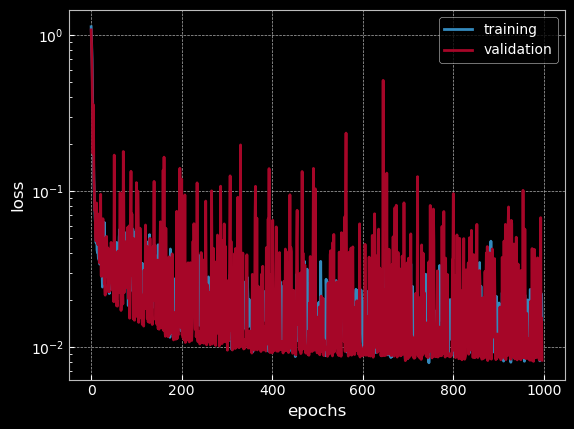

In [28]:
train_ = True
cvc = cnn_vae_classifier(input_shape, num_class).to(device)
cvc_optimizer = torch.optim.Adam(cvc.parameters(), lr=0.001)

if train_:
    train(cvc, cvc.compute_loss, (train_x, train_y), cvc_optimizer, (val_x, val_y), 
          beta=None, epochs=1000, batch_size=32, clip_grad_norm=1.0)
else:
    cvc_state_dict = copy.deepcopy(torch.load('cvc_state_dict.zip'))
    cvc.load_state_dict(cvc_state_dict)

In [13]:
cvc.compute_loss((val_x, val_y), peek=True)

{'Latent': 0.0017413150053471327,
 'Reconstruction': 0.01653681881725788,
 'Classification': 10.21835708618164,
 'Loss': 10.236635208129883}

In [14]:
#torch.save(cvc.state_dict(), 'cvc_state_dict')

Label : 1


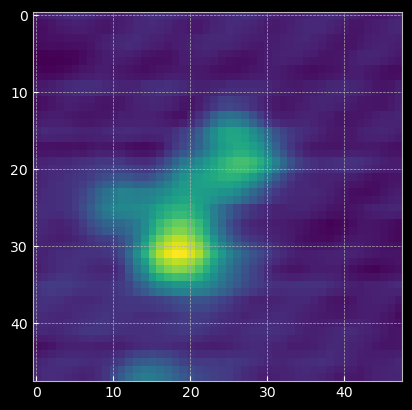

Class:  1


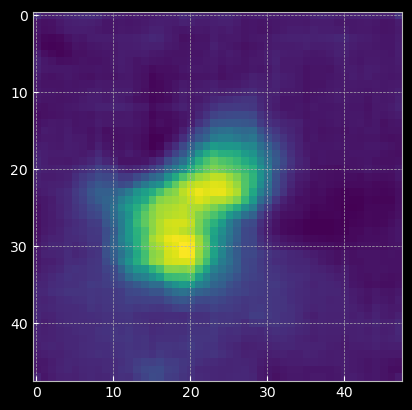

In [102]:
data = random.sample(list(zip(val_x, val_y)), 1)
x, y = data[0][0], data[0][1]
print("Label :", y.cpu().numpy())
imshow(x.cpu().numpy().squeeze())
plt.show()
out = cvc(x.unsqueeze(0))
x_hat = out['reconstruction']
l = out['class']
print("Class: ", np.argmax(l.detach().cpu().numpy()))
imshow(x_hat.cpu().detach().numpy().squeeze())
plt.show()